# Sondierung — taugt PaddleOCR-VL-1.5 für Stufe 2?

**KI-gestützte Dokumentenaufbereitung · Referenz-Implementierung**

Dieses Notebook baut noch keine Pipeline. Es beantwortet eine einzige Frage, bevor
Aufwand in Stufe 2 fließt: **liefert das Modell auf unseren Ausschnitten brauchbaren
Text — und woran erkennen wir das?**

Es hängt nicht an Notebook 1. Gebraucht werden nur die abgelegte Befund-JSON und
die zugehörige PDF-Datei.

## Der Messtrick

„Sieht gut aus" ist keine Aussage. Für die born-digital-Seiten haben wir aber eine
**unabhängige zweite Quelle**: den Textlayer des PDF. PyMuPDF liest ihn ohne jedes
Modell aus, exakt für dieselbe Region.

Für Zimbardo und Wahrnehmungspsychologie ist dieser Layer vertrauenswürdig — also
ist er ein Referenzmaßstab. Für den Tietze-Schenk-Scan ist er es nicht; dort muss
die Ähnlichkeit **schlecht** sein, und das ist kein Fehler, sondern der Beweis für
die These aus Abschnitt 2 von Notebook 1.

> ⚠️ Was hier gemessen wird, ist **Übereinstimmung, nicht Wahrheit**. Bei einer
> Abweichung kann jede der beiden Quellen recht haben. Genau deshalb kommen die
> Ausschnitte am Ende zum Anschauen auf den Schirm.

## Voraussetzungen

1. LM Studio läuft, der lokale Server ist gestartet (Developer-Tab, Port 1234).
2. Das Modell ist geladen:
   - **Windows:** `PaddleOCR-VL-1.5.gguf` **und** `PaddleOCR-VL-1.5-mmproj.gguf`
     im selben Ordner. Ohne mmproj lädt LM Studio ein reines Textmodell.
   - **macOS:** `mlx-community/PaddleOCR-VL-1.5-bf16`. Der Vision-Tower steckt in
     denselben Safetensors, es gibt keine getrennte Projektordatei.
3. Neben dem Modellnamen muss ein Augen-Symbol stehen. Fehlt es, nimmt das Modell
   keine Bilder an, und alles Weitere ist zwecklos.

```bash
pip install requests pymupdf opencv-python-headless numpy
```

In [1]:
from __future__ import annotations

import base64
import difflib
import json
import re
import time
from pathlib import Path

import cv2
import numpy as np
import pymupdf
import requests

# --- Anzupassen
LMS_URL   = "http://localhost:1234/v1"
MODELL_ID = None           # None = erstes geladenes Modell nehmen

BEFUND    = Path("befunde/zimbardo_stufe1.json")
PDF       = Path("uploads/Zimbardo_Psychologie_18Aufl_Extracted.pdf")

PROBE_DPI = 300            # Ausschnitte hoeher aufloesen als die Layout-Analyse
RAND_PX   = 8              # Luft um die Box, bei 200 dpi gemessen

for p in (BEFUND, PDF):
    print(f"{'vorhanden' if p.exists() else 'FEHLT':10s} {p}")

vorhanden  befunde/zimbardo_stufe1.json
vorhanden  uploads/Zimbardo_Psychologie_18Aufl_Extracted.pdf


---
## 1. Verbindung prüfen

Zuerst die billigste aller Fragen: antwortet der Server überhaupt, und was hat er
geladen? Diese Zelle spart erfahrungsgemäß die meiste Zeit — die häufigste Ursache
für „das Modell funktioniert nicht" ist ein nicht gestarteter Server oder ein
anderes geladenes Modell als gedacht.

In [2]:
def geladene_modelle() -> list[str]:
    antwort = requests.get(f"{LMS_URL}/models", timeout=10)
    antwort.raise_for_status()
    return [m["id"] for m in antwort.json()["data"]]

try:
    modelle = geladene_modelle()
    print("Server erreichbar. Geladen:")
    for m in modelle:
        print(f"  {m}")
    if MODELL_ID is None:
        MODELL_ID = modelle[0]
    print(f"\nVerwendet: {MODELL_ID}")
except Exception as e:
    print("Server nicht erreichbar:", e)
    print("\nPrüfen: LM Studio -> Developer -> Server starten (Port 1234).")

Server erreichbar. Geladen:
  mlx-community/paddleocr-vl-1.5
  paddlepaddle/paddleocr-vl-1.5
  guppylm-12m
  qwen_qwen3-1.7b
  google/gemma-4-12b
  text-embedding-multilingual-e5-large-instruct
  text-embedding-nomic-embed-text-v1.5

Verwendet: mlx-community/paddleocr-vl-1.5


---
## 2. Ausschnitte erzeugen

Die Faustregel aus Notebook 1: **Layout auf der verkleinerten Kopie, Ausschnitte aus
dem Original.** Der Befund trägt seine Boxen bei 200 dpi; für die Erkennung rendern
wir die Seite neu bei 300 dpi und skalieren die Boxen mit.

Der Rand ist der einzige freie Parameter. Zu wenig schneidet Unterlängen und
Formelklammern ab, zu viel zieht Nachbartext mit hinein. 8 px bei 200 dpi ist ein
Startwert, kein Ergebnis — er gehört am Goldset justiert.

In [3]:
befund = json.loads(BEFUND.read_text(encoding="utf-8"))
faktor = PROBE_DPI / befund["render_dpi"]

dok = pymupdf.open(PDF)
pg = dok[befund["seite"]]
pix = pg.get_pixmap(dpi=PROBE_DPI)
seite_rgb = np.frombuffer(pix.samples, dtype=np.uint8)
seite_rgb = np.ascontiguousarray(
    seite_rgb.reshape(pix.height, pix.width, pix.n)[:, :, :3])

print(f"Befund  {befund['bild_breite_px']} x {befund['bild_hoehe_px']} px "
      f"bei {befund['render_dpi']} dpi, {len(befund['bloecke'])} Blöcke")
print(f"Probe   {seite_rgb.shape[1]} x {seite_rgb.shape[0]} px "
      f"bei {PROBE_DPI} dpi, Faktor {faktor:.2f}")


def ausschnitt(block: dict) -> np.ndarray:
    """Block -> RGB-Ausschnitt aus der hoch aufgelösten Seite."""
    bx = block["bbox"]
    r = RAND_PX * faktor
    h, b = seite_rgb.shape[:2]
    x0 = int(max(0, bx["x0"] * faktor - r))
    y0 = int(max(0, bx["y0"] * faktor - r))
    x1 = int(min(b, bx["x1"] * faktor + r))
    y1 = int(min(h, bx["y1"] * faktor + r))
    return seite_rgb[y0:y1, x0:x1]


def als_datenurl(bild_rgb: np.ndarray) -> str:
    """RGB-Array -> PNG als data-URL, wie die Chat-Schnittstelle sie erwartet."""
    ok, puffer = cv2.imencode(".png", bild_rgb[:, :, ::-1])   # cv2 will BGR
    if not ok:
        raise RuntimeError("PNG-Kodierung fehlgeschlagen")
    return "data:image/png;base64," + base64.b64encode(puffer).decode("ascii")


for blk in befund["bloecke"][:5]:
    a = ausschnitt(blk)
    print(f"  #{blk['id']:2d} {blk['pp_label']:18s} {a.shape[1]:5d} x {a.shape[0]:4d} px")

Befund  1653 x 2204 px bei 200 dpi, 13 Blöcke
Probe   2479 x 3305 px bei 300 dpi, Faktor 1.50
  # 0 header               823 x   71 px
  # 1 table               1416 x 1397 px
  # 2 inline_formula       249 x   82 px
  # 3 chart               1129 x  704 px
  # 4 figure_title        1892 x  327 px


---
## 3. Das Prompt-Vokabular

PaddleOCR-VL wird nicht mit freien Anweisungen gesteuert, sondern mit einem festen
Satz von sechs Präfixen. Das ist die Nahtstelle zu Stufe 1: **das `pp_label` wählt
den Prompt aus.**

`Spotting:` fehlt in der Tabelle unten mit Absicht — es würde Text *und* Position
liefern, aber die Position kennen wir bereits aus Stufe 1. Es bräuchte außerdem eine
Änderung an der mmproj-Datei (`clip.vision.image_max_pixels` auf 1605632).

In [4]:
PROMPT_FUER: dict[str, str | None] = {
    # Text in allen Erscheinungsformen
    "text": "OCR:", "paragraph_title": "OCR:", "doc_title": "OCR:",
    "abstract": "OCR:", "aside_text": "OCR:", "footnote": "OCR:",
    "vision_footnote": "OCR:", "figure_title": "OCR:", "content": "OCR:",
    "header": "OCR:", "footer": "OCR:", "number": "OCR:",
    "reference": "OCR:", "reference_content": "OCR:", "algorithm": "OCR:",
    "vertical_text": "OCR:", "formula_number": "OCR:",
    # Spezialisierte Köpfe
    "display_formula": "Formula Recognition:",
    "inline_formula": "Formula Recognition:",
    "table": "Table Recognition:",
    "chart": "Chart Recognition:",
    "seal": "Seal Recognition:",
    # Kein Aufruf - Ausschnitt wird nur abgelegt
    "image": None, "header_image": None, "footer_image": None,
}

vorhanden = sorted({b["pp_label"] for b in befund["bloecke"]})
fehlend = [l for l in vorhanden if l not in PROMPT_FUER]
assert not fehlend, f"ohne Prompt-Zuordnung: {fehlend}"

for l in vorhanden:
    print(f"  {l:18s} -> {PROMPT_FUER[l] or '(kein Aufruf)'}")

  chart              -> Chart Recognition:
  figure_title       -> OCR:
  footer             -> OCR:
  header             -> OCR:
  inline_formula     -> Formula Recognition:
  number             -> OCR:
  paragraph_title    -> OCR:
  table              -> Table Recognition:
  text               -> OCR:


---
## 4. Der Aufruf

LM Studio spricht die OpenAI-kompatible Schnittstelle. Bild und Prompt gehen als
zwei Teile derselben Nachricht — **Bild zuerst**, weil das Modell die Aufgabe nach
dem Bild erwartet.

`temperature=0` ist hier keine Geschmacksfrage. Für eine Sondierung braucht es
Wiederholbarkeit; ein Sampling-Ergebnis, das beim zweiten Lauf anders aussieht,
lässt sich nicht bewerten.

In [5]:
def erkennen(bild_rgb: np.ndarray, prompt: str, max_tokens: int = 1024) -> tuple[str, float]:
    """Ausschnitt + Prompt -> (Antworttext, Dauer in Sekunden)."""
    nutzlast = {
        "model": MODELL_ID,
        "temperature": 0,
        "max_tokens": max_tokens,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": als_datenurl(bild_rgb)}},
                {"type": "text", "text": prompt},
            ],
        }],
    }
    t0 = time.perf_counter()
    antwort = requests.post(f"{LMS_URL}/chat/completions", json=nutzlast, timeout=300)
    dauer = time.perf_counter() - t0
    antwort.raise_for_status()
    return antwort.json()["choices"][0]["message"]["content"], dauer


# --- Einzeltest an einem Textblock: läuft es überhaupt?
probe = next(b for b in befund["bloecke"] if b["pp_label"] == "text")
text, dauer = erkennen(ausschnitt(probe), "OCR:")
print(f"#{probe['id']} {probe['pp_label']}   {dauer:.2f} s   {len(text)} Zeichen\n")
print(text[:600])

#7 text   2.17 s   298 Zeichen

Töne besser unterscheiden kann als die Intensität zweier Lichtpunkte. Diese wiederum sind durch einen kleineren EMU besser zu entdecken als Geruchs- oder Geschmacksunterschiede. Ihre Getränkefabrik bräuchte eine relativ große Menge zusätzlichen Zuckers, um eine merklich süßere Cola zu produzieren!


### Wenn hier nichts kommt

| Symptom | wahrscheinliche Ursache |
|---|---|
| HTTP 400, „model does not support images" | mmproj fehlt oder liegt im falschen Ordner |
| leere Antwort, keine Fehlermeldung | Chat-Vorlage passt nicht — bekanntes Problem der jungen `paddleocr`-Integration |
| Antwort beschreibt das Bild, statt es zu lesen | falsches Modell geladen |
| Zeitüberschreitung | Modell läuft auf CPU statt GPU/Metal |

Der zweite Fall ist der unangenehmste, weil er wie ein Erfolg aussieht. Deshalb
prüft die nächste Zelle nicht nur, *dass* etwas kommt, sondern *was*.

---
## 5. Gegen den Textlayer messen

Jetzt die eigentliche Sondierung. Für jeden Textblock:

1. PyMuPDF liest den Textlayer **derselben Region** — ohne Modell, ohne Bild.
2. Das VLM liest den Ausschnitt.
3. Beide werden normalisiert und mit `difflib` verglichen.

Die Normalisierung entfernt Zeilenumbrüche, Mehrfachleerzeichen und Trennstriche am
Zeilenende. Ohne sie misst man Formatierungsunterschiede statt Lesefehler.

In [6]:
def normalisiert(s: str) -> str:
    """Weichzeichnen, was für den Vergleich nicht zählt."""
    s = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", s)   # Trennstrich am Zeilenende
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()


def textlayer(block: dict) -> str:
    """Was PyMuPDF in derselben Region liest - die unabhängige zweite Quelle."""
    bx = block["bbox"]
    f = 72.0 / befund["render_dpi"]        # Bildpixel -> PDF-Punkte
    rechteck = pymupdf.Rect(bx["x0"] * f, bx["y0"] * f, bx["x1"] * f, bx["y1"] * f)
    return pg.get_text("text", clip=rechteck)


def aehnlichkeit(a: str, b: str) -> float:
    return difflib.SequenceMatcher(None, normalisiert(a), normalisiert(b)).ratio()


NUR_TEXT = {l for l, p in PROMPT_FUER.items() if p == "OCR:"}
kandidaten = [b for b in befund["bloecke"] if b["pp_label"] in NUR_TEXT]

ERGEBNISSE = []
print(f"{'id':>3} {'label':18s} {'sim':>5} {'s':>6} {'VLM':>6} {'PDF':>6}")
print("-" * 52)
for blk in kandidaten:
    aus = ausschnitt(blk)
    vlm, dauer = erkennen(aus, "OCR:")
    pdf = textlayer(blk)
    sim = aehnlichkeit(vlm, pdf)
    ERGEBNISSE.append({"block": blk, "vlm": vlm, "pdf": pdf,
                       "sim": sim, "dauer": dauer, "bild": aus})
    print(f"{blk['id']:3d} {blk['pp_label']:18s} {sim:5.2f} {dauer:6.2f} "
          f"{len(vlm):6d} {len(pdf):6d}")

if ERGEBNISSE:
    schnitt = sum(e["sim"] for e in ERGEBNISSE) / len(ERGEBNISSE)
    gesamt = sum(e["dauer"] for e in ERGEBNISSE)
    print(f"\nMittlere Ähnlichkeit {schnitt:.2f}   "
          f"{gesamt:.1f} s für {len(ERGEBNISSE)} Blöcke "
          f"({gesamt / len(ERGEBNISSE):.2f} s je Block)")

 id label                sim      s    VLM    PDF
----------------------------------------------------
  0 header              1.00   0.33     36     37
  4 figure_title        0.99   2.37    833    843
  5 figure_title        0.99   0.33     53     56
  7 text                1.00   0.89    298    304
  8 paragraph_title     1.00   0.27     48     50
  9 text                1.00   0.79    291    301
 10 footer              1.00   0.21     12     14
 11 number              0.93   0.22      8      8
 12 footer              0.97   0.33     58     58

Mittlere Ähnlichkeit 0.99   5.7 s für 9 Blöcke (0.64 s je Block)


### Wie die Zahlen zu lesen sind

| Ähnlichkeit | Deutung |
|---|---|
| über 0,95 | beide Quellen sagen dasselbe — für born-digital der Normalfall |
| 0,80 bis 0,95 | meist Zeilenumbrüche, Ligaturen, Anführungszeichen. Ausschnitt ansehen |
| unter 0,80 | eine der beiden Quellen liegt daneben. **Welche, sagt die Zahl nicht** |

Der letzte Punkt ist wichtig genug für eine Wiederholung: eine niedrige Ähnlichkeit
ist ein **Hinweis auf eine Abweichung**, keine Schuldzuweisung. Beim Tietze-Schenk
wird sie niedrig sein, weil der Textlayer falsch ist — nicht das Modell.

Deshalb ist die nächste Zelle keine Zierde, sondern der Kern des Verfahrens.

#11 number  score 0.69  Ähnlichkeit 0.93

--- VLM ---
118 Exer

--- Textlayer ---
118
Exe



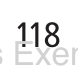

#12 footer  score 0.77  Ähnlichkeit 0.97

--- VLM ---
Inplar von Herr Hans Wurst vom 27.04.2011, Lesen & Drucken

--- Textlayer ---
mplar von Herr Hans Wurst vom 27.04.2011, Lesen & Drucken



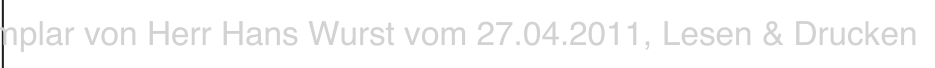

#5 figure_title  score 0.62  Ähnlichkeit 0.99

--- VLM ---
Weber‘sche Konstanten für ausgewählte Reizdimensionen

--- Textlayer ---
Weber‘sche Konstante n für 
ausgewählte Reizdimensionen



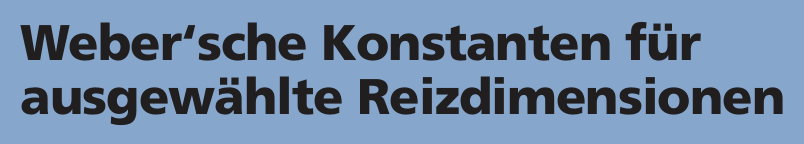

In [7]:
from IPython.display import Image, display

# Die drei schwächsten Fälle im Bild ansehen - Zahlen allein entscheiden nicht.
AUSGABE = Path("sondierung")
AUSGABE.mkdir(exist_ok=True)

for e in sorted(ERGEBNISSE, key=lambda e: e["sim"])[:3]:
    blk = e["block"]
    ziel = AUSGABE / f"block_{blk['id']:02d}.png"
    cv2.imwrite(str(ziel), e["bild"][:, :, ::-1])

    print("=" * 70)
    print(f"#{blk['id']} {blk['pp_label']}  score {blk['score']:.2f}  "
          f"Ähnlichkeit {e['sim']:.2f}")
    print(f"\n--- VLM ---\n{e['vlm'][:400]}")
    print(f"\n--- Textlayer ---\n{e['pdf'][:400]}")
    display(Image(str(ziel), width=620))

---
## 6. Die Spezialköpfe

`OCR:` ist nur einer von sechs Prompts. Für Tabellen, Formeln und Diagramme gibt es
eigene, und ihre Ausgabe ist strukturiert — HTML für Tabellen, LaTeX für Formeln.

Gegen den Textlayer lässt sich das **nicht** messen: PyMuPDF liefert dort lose
Zeichen ohne Struktur, und genau die Struktur ist der Mehrwert. Hier hilft nur
hinsehen.

#1 table  Prompt 'Table Recognition:'  2.82 s  305 Zeichen

<fcel>A. Eben merklich längere Striche<fcel>B. Standard-strichlänge<fcel>L_{a} - L_{b} = \(\Delta L\)<nl><fcel>11 mm<fcel>10 mm<fcel>11,0 - 10,0 = 1,0<nl><fcel>16,5 mm<fcel>15 mm<fcel>16,5 - 15,0 = 1,5<nl><fcel>22 mm<fcel>20 mm<fcel>22,0 - 20,0 = 2,0<nl><fcel>27,5 mm<fcel>25 mm<fcel>27,5 - 25,0 = 2,5<nl>


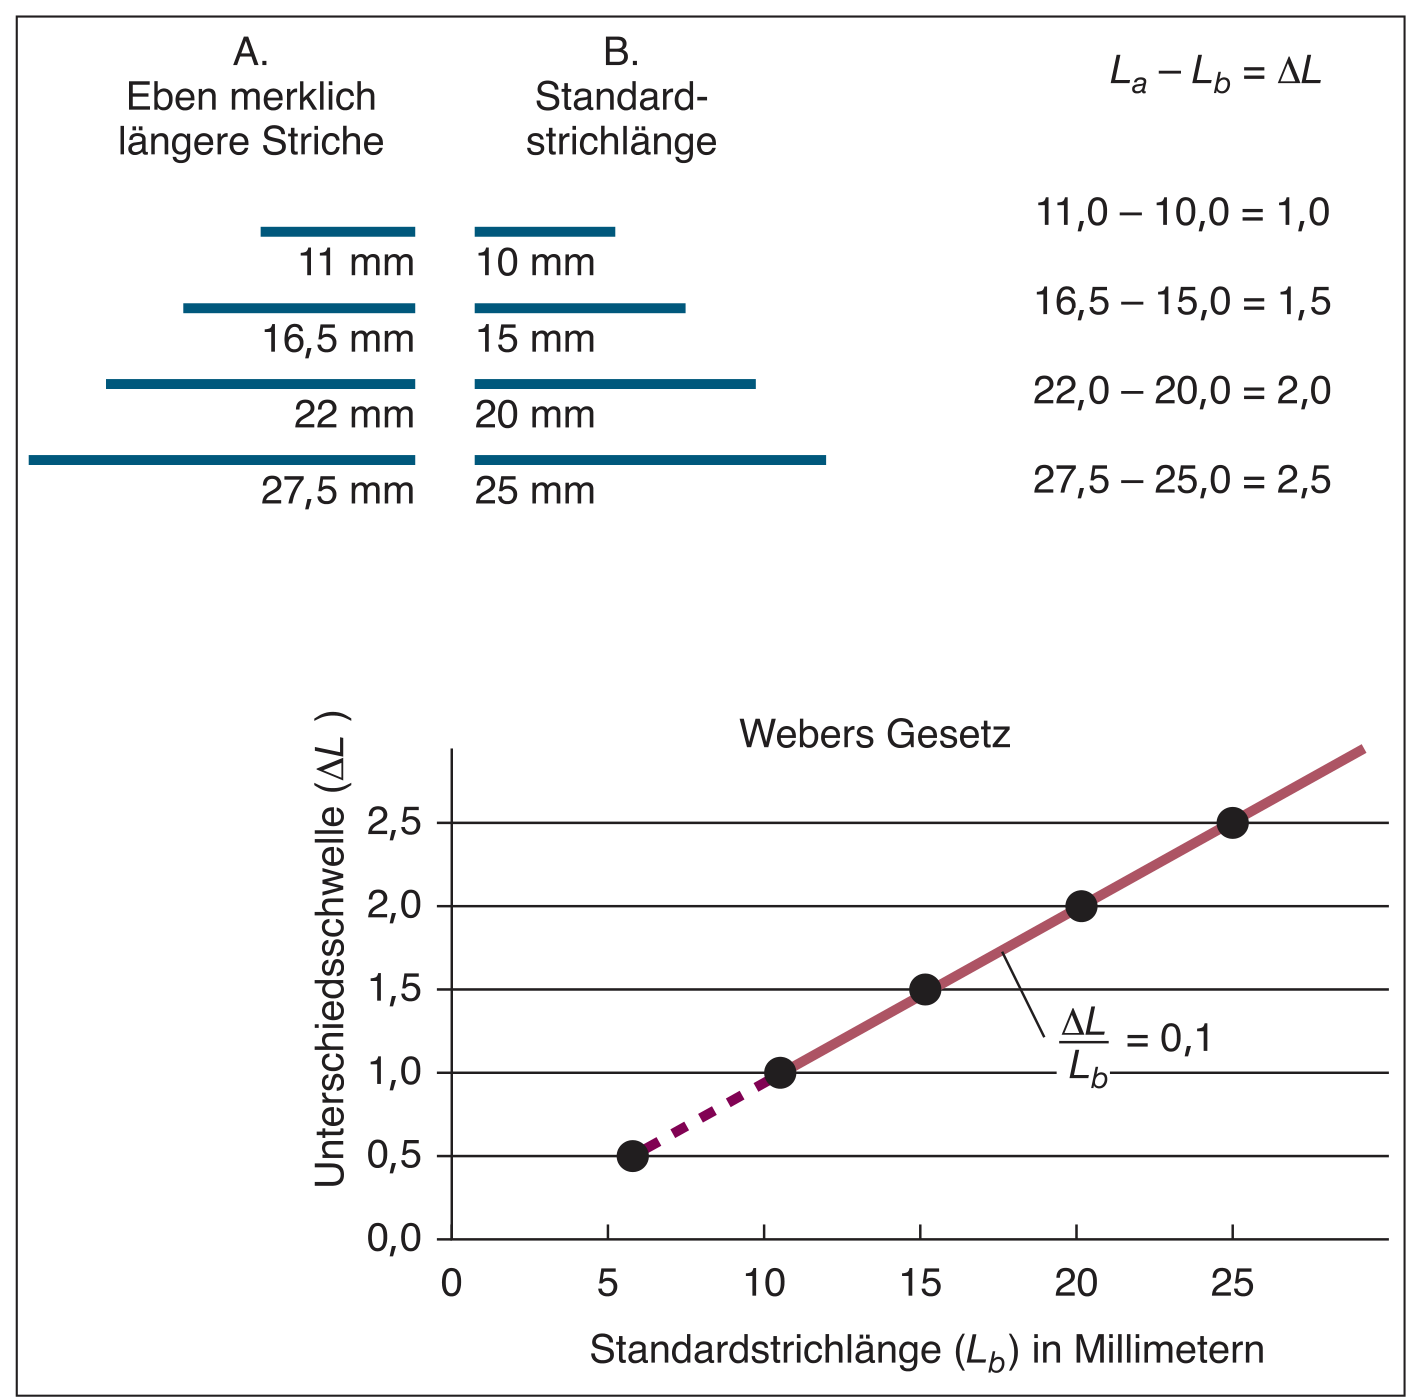

#2 inline_formula  Prompt 'Formula Recognition:'  0.26 s  24 Zeichen

\[L_{a}-L_{b}=\Delta L\]


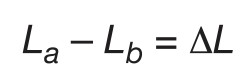

#3 chart  Prompt 'Chart Recognition:'  1.86 s  122 Zeichen

Standardstrichlänge (L_b) in Millimetern | Unterschiedsschwelle (ΔL/L_b = 0,1)
6 | 0.5
10 | 1.0
15 | 1.5
20 | 2.0
25 | 2.5


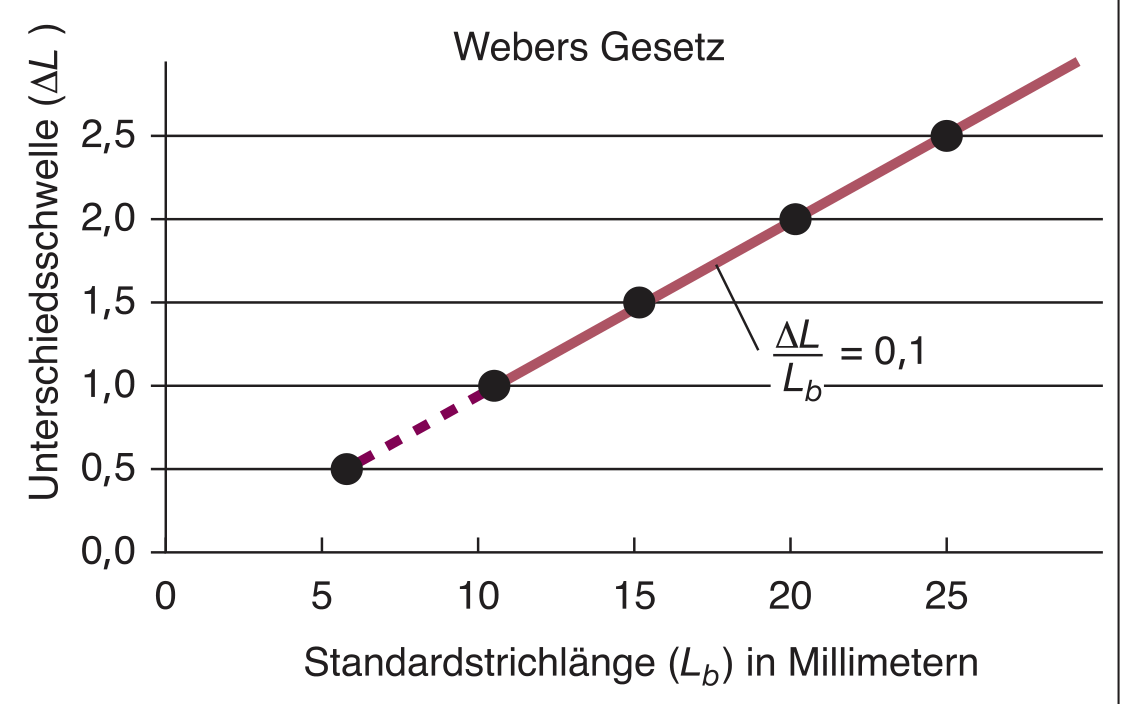

#6 table  Prompt 'Table Recognition:'  1.14 s  279 Zeichen

<fcel>Reizdimension<fcel>Weber'sche Konstante (k)<nl><fcel>Schallfrequenz<fcel>0,003<nl><fcel>Lichtintensität<fcel>0,01<nl><fcel>Geruchs-konzentration<fcel>0,07<nl><fcel>Druckintensität<fcel>0,14<nl><fcel>Schallintensität<fcel>0,15<nl><fcel>Geschmacks-konzentration<fcel>0,20<nl>


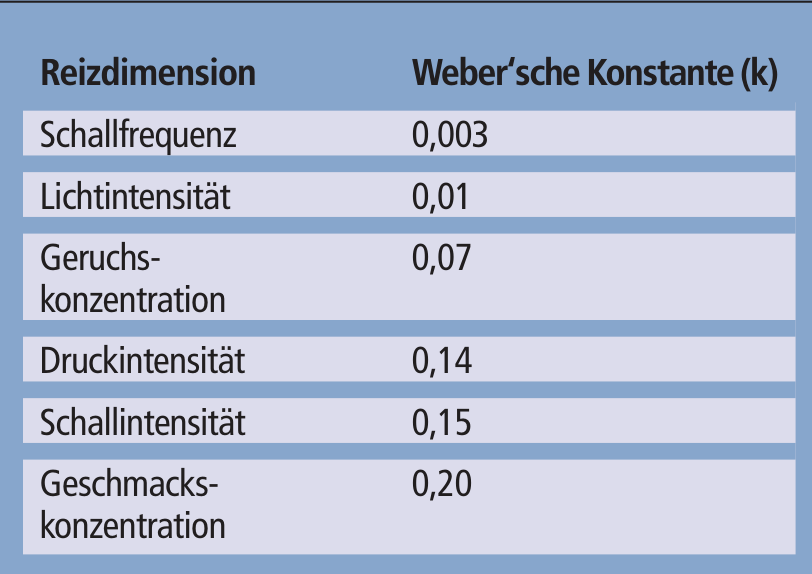

In [8]:
SPEZIAL = {l for l, p in PROMPT_FUER.items() if p and p != "OCR:"}

for blk in [b for b in befund["bloecke"] if b["pp_label"] in SPEZIAL]:
    prompt = PROMPT_FUER[blk["pp_label"]]
    aus = ausschnitt(blk)
    text, dauer = erkennen(aus, prompt, max_tokens=2048)

    ziel = AUSGABE / f"spezial_{blk['id']:02d}.png"
    cv2.imwrite(str(ziel), aus[:, :, ::-1])

    print("=" * 70)
    print(f"#{blk['id']} {blk['pp_label']}  Prompt '{prompt}'  "
          f"{dauer:.2f} s  {len(text)} Zeichen\n")
    print(text[:1200])
    display(Image(str(ziel), width=620))

---
## 7. Die Gegenprobe

Ein Ergebnis, das man nicht falsifizieren kann, ist keines. Die folgende Zelle
schickt **denselben Ausschnitt mit allen sechs Prompts** durch.

Zwei Ausgänge sind möglich, und beide sind lehrreich:

- Die Ausgaben unterscheiden sich deutlich → das Prompt-Vokabular wirkt tatsächlich,
  und die Zuordnung `pp_label → Prompt` aus Abschnitt 3 ist ihre Mühe wert.
- Die Ausgaben sind praktisch gleich → die Präfixe werden nicht ausgewertet.
  Dann stimmt vermutlich die Chat-Vorlage nicht, und alles bisher Gemessene steht
  unter Vorbehalt.

Der zweite Fall ist der Grund, warum diese Zelle existiert.

In [9]:
tabelle = next((b for b in befund["bloecke"] if b["pp_label"] == "table"), None)
if tabelle is None:
    print("Kein table-Block auf dieser Seite - nehme den ersten Block.")
    tabelle = befund["bloecke"][0]

aus = ausschnitt(tabelle)
print(f"Testobjekt: #{tabelle['id']} {tabelle['pp_label']}\n")

ausgaben = {}
for prompt in ["OCR:", "Formula Recognition:", "Table Recognition:",
               "Chart Recognition:", "Seal Recognition:"]:
    text, dauer = erkennen(aus, prompt, max_tokens=512)
    ausgaben[prompt] = text
    print(f"--- {prompt} ({dauer:.2f} s, {len(text)} Zeichen)")
    print(text[:220].replace("\n", " ") + "\n")

paare = [(a, b) for i, a in enumerate(ausgaben) for b in list(ausgaben)[i+1:]]
maximum = max(aehnlichkeit(ausgaben[a], ausgaben[b]) for a, b in paare)
print(f"Höchste Ähnlichkeit zwischen zwei Prompts: {maximum:.2f}")
print("Über 0.95 heißt: die Präfixe wirken nicht. Chat-Vorlage prüfen.")

Testobjekt: #1 table

--- OCR: (2.86 s, 235 Zeichen)
A. Eben merklich längere Striche B. Standard-strichlänge L_a - L_b = ΔL 11 mm 10 mm 16,5 mm 15 mm 22 mm 27.5 mm 20 mm 25 mm 11,0 - 10,0 = 1,0 16,5 - 15,0 = 1,5 22,0 - 20,0 = 2,0 27,5 - 25,0 = 2,5 Webers Gesetz Unterschie

--- Formula Recognition: (4.11 s, 855 Zeichen)
\[\begin{array}{r l r}&{}&{\mathrm{L}_{a}-L_{b}=\Delta L}\\ &{}&{\mathrm{E}_{b e n~m e r k l i c h}}\\ &{}&{\mathrm{l a}_{a g e r e~S t r i c h e}}\\ &{}&{\mathrm{s t r i c h l a n g e}}\\ &{}&{\mathrm{11~m m}}\\ &{}&{\m

--- Table Recognition: (2.55 s, 305 Zeichen)
<fcel>A. Eben merklich längere Striche<fcel>B. Standard-strichlänge<fcel>L_{a} - L_{b} = \(\Delta L\)<nl><fcel>11 mm<fcel>10 mm<fcel>11,0 - 10,0 = 1,0<nl><fcel>16,5 mm<fcel>15 mm<fcel>16,5 - 15,0 = 1,5<nl><fcel>22 mm<fce

--- Chart Recognition: (2.37 s, 160 Zeichen)
Standardstrichlänge (L_b) in Millimetern | Webers Gesetz | Unterschiedsschwelle (ΔL) 5.0 | 0.5 |   10.0 | 1.0 | 0.5 15.0 | 1.5 |   20.0 | 2.0 | 

---
## 8. Entscheidungsgrundlage

Nach diesem Notebook lassen sich vier Fragen mit Zahlen statt mit Gefühl beantworten:

| # | Frage | woran erkennbar |
|---|---|---|
| 1 | Nimmt das Modell überhaupt Bilder an? | Abschnitt 4 liefert Text |
| 2 | Ist die Erkennung brauchbar? | mittlere Ähnlichkeit in Abschnitt 5 |
| 3 | Wirken die sechs Prompts? | Abschnitt 7, höchste Paar-Ähnlichkeit unter 0,95 |
| 4 | Ist es schnell genug? | Sekunden je Block, hochgerechnet auf einen Seitenumfang |

Zu Punkt 4 eine Überschlagsrechnung: dreizehn Blöcke pro Seite bei einer Sekunde je
Block sind dreizehn Sekunden. Ein Buchkapitel mit 30 Seiten liegt damit bei etwa
sieben Minuten — das entscheidet, ob Stufe 2 interaktiv läuft oder als Stapellauf.

Erst wenn diese vier Antworten vorliegen, lohnt sich Stufe 2 als richtiges Notebook:
`SeitenBefund` einlesen, Feld `text` füllen, wieder ablegen.

### Was hier bewusst nicht geprüft wird

- **Bildblöcke.** `image` und Verwandte bekommen keinen Aufruf. Sie werden in
  Stufe 2 als Ausschnitt abgelegt und in Stufe 4 vom Vision-LLM beschrieben.
- **Der Rand.** `RAND_PX = 8` ist gesetzt, nicht optimiert. Wenn Abschnitt 5
  systematisch abgeschnittene Wortanfänge zeigt, ist das die erste Stellschraube.
- **Der Tietze-Schenk-Scan.** Bitte einmal die Pfade oben umstellen und die Zellen
  erneut laufen lassen. Erwartung: deutlich niedrigere Ähnlichkeit — und der Blick
  auf die Ausschnitte in Abschnitt 5 zeigt dann, dass das VLM recht hat und der
  Textlayer nicht.